# Exploratory Data Analysis — LATAM Conflict Event Data (ACLED)

Dataset: `LATAM 20241209.csv` (~434K events). Goals:
1. Understand the shape and structure of the data
2. Identify the most common feature values (event types, actors, countries)
3. Test which factors are statistically significant (e.g., drivers of fatalities and civilian targeting)


## Setup

Import the core stack — `polars`/`numpy` for data wrangling, `matplotlib`/`seaborn` for plots, and `scipy.stats` for the significance tests in Section 9 — and set display/plot defaults sized for a wide, 31-column dataset.

In [18]:
# 1. Import Required Libraries
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pl.Config.set_tbl_cols(-1)          # show all columns
pl.Config.set_tbl_rows(10)
pl.Config.set_fmt_str_lengths(80)   # don't truncate long text like `notes`


polars.config.Config

## 1. Load the Dataset

Read the raw ACLED CSV and parse `event_date` as a proper datetime. Each row is one recorded conflict, political-violence, or protest event, with actor, location, source, and fatality details — the atomic unit for everything that follows. The preview below confirms the file loaded cleanly and shows the shape of a typical row (e.g., a peaceful protest in La Paz, an armed clash in Rio de Janeiro).

In [19]:
# 2. Load the Dataset
df = pl.read_csv("LATAM 20241209.csv", infer_schema_length=None).with_columns(
    pl.col("event_date").str.strptime(pl.Date, "%d %B %Y")
)
df.head()


event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,actor2,assoc_actor_2,inter2,interaction,civilian_targeting,iso,region,country,admin1,admin2,admin3,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
str,date,i64,i64,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,f64,f64,i64,str,str,str,i64,str,i64
"""BOL6827""",2024-11-29,2024,1,"""Demonstrations""","""Protests""","""Peaceful protest""","""Protesters (Bolivia)""","""Health Workers (Bolivia)""","""Protesters""",null,null,null,"""Protesters only""",null,68,"""South America""","""Bolivia""","""La Paz""","""Murillo""","""Nuestra Senora de La Paz""","""La Paz""",-16.4957,-68.1336,1,"""El Diario (Bolivia)""","""National""","""On 29 November 2024, in La Paz (La Paz), for a second day of the week, a group o…",0,"""crowd size=no report""",1733203621
"""BRA91741""",2024-11-29,2024,1,"""Political violence""","""Battles""","""Armed clash""","""CV: Red Command""",null,"""Political militia""","""Unidentified Gang and/or Police Militia""",null,"""Political militia""","""Political militia-Political militia""",null,76,"""South America""","""Brazil""","""Rio de Janeiro""","""Rio de Janeiro""",null,"""Rio de Janeiro - West Zone""",-22.9147,-43.4879,1,"""Crimes News RJ""","""New media""","""On 29 November 2024, in Rio de Janeiro - West Zone (Rio de Janeiro), members of …",1,null,1733203622
"""BRA91747""",2024-11-29,2024,1,"""Political violence""","""Battles""","""Armed clash""","""Military Forces of Brazil (2023-) Military Police""",null,"""State forces""","""BDM: Bonde do Maluco""",null,"""Political militia""","""State forces-Political militia""",null,76,"""South America""","""Brazil""","""Bahia""","""Salvador""",null,"""Salvador""",-12.9711,-38.5108,1,"""Alo Juca; Bahia 190""","""Subnational""","""On 29 November 2024, in Salvador - Itapua (Bahia), military police officers exch…",1,null,1733203622
"""BRA91829""",2024-11-29,2024,1,"""Political violence""","""Battles""","""Armed clash""","""Unidentified Armed Group (Brazil)""",null,"""Political militia""","""Unidentified Armed Group (Brazil)""",null,"""Political militia""","""Political militia-Political militia""",null,76,"""South America""","""Brazil""","""Rio de Janeiro""","""Rio de Janeiro""",null,"""Rio de Janeiro - North Zone""",-22.8569,-43.3008,1,"""OTT-RJ""","""New media""","""On 29 November 2024, in Rio de Janeiro - North Zone (Rio de Janeiro), unknown sh…",0,null,1733203622
"""BRA91830""",2024-11-29,2024,1,"""Political violence""","""Battles""","""Armed clash""","""Unidentified Armed Group (Brazil)""",null,"""Political militia""","""Unidentified Armed Group (Brazil)""",null,"""Political militia""","""Political militia-Political militia""",null,76,"""South America""","""Brazil""","""Rio de Janeiro""","""Rio de Janeiro""",null,"""Rio de Janeiro - West Zone""",-22.9147,-43.4879,1,"""OTT-RJ""","""New media""","""On 29 November 2024, in Rio de Janeiro - West Zone (Rio de Janeiro), unknown sho…",0,null,1733203622


## 2. Data Shape & Structure

Check the size of the dataset, each column's type, and how complete it is with `.info()`, and confirm the date range covered.

**What it shows:** The dataset spans **433,837 events across 31 columns**, covering **January 2018 – November 2024** (~7 years). Most fields are fully populated, but several — `assoc_actor_2`, `admin3`, `civilian_targeting`, `assoc_actor_1`, `actor2`/`inter2`, `tags` — have substantial gaps, quantified in Section 4. This is a large, well-structured panel suited to both categorical breakdowns and time-series analysis.

In [20]:
# 3. Inspect Data Shape and Structure
print(f"Shape: {df.height:,} rows x {df.width} columns\n")
print(f"Date range: {df['event_date'].min()} to {df['event_date'].max()}\n")

null_counts = df.null_count().row(0)
info = pl.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "non_null": [df.height - n for n in null_counts],
    "null": null_counts,
})
info


Shape: 433,837 rows x 31 columns

Date range: 2018-01-01 to 2024-11-29



column,dtype,non_null,null
str,str,i64,i64
"""event_id_cnty""","""String""",433837,0
"""event_date""","""Date""",433837,0
"""year""","""Int64""",433837,0
"""time_precision""","""Int64""",433837,0
"""disorder_type""","""String""",433837,0
…,…,…,…
"""source_scale""","""String""",433837,0
"""notes""","""String""",433837,0
"""fatalities""","""Int64""",433837,0


## 3. Summary Statistics

Describe the numeric columns (`year`, `fatalities`, coordinates, precision flags) and the categorical columns (unique value counts, most frequent category) for a first read on distribution and cardinality.

**What it shows:** Fatalities are heavily right-skewed — the median event has **0 fatalities**, the mean is just **0.37**, but the single deadliest event killed **134** people. Geographically the data centers on Latin America (mean latitude ~8°N, longitude ~-77°W) with a long reach into the U.S. and southern South America. Among categoricals, `event_type` has only 6 values dominated by **Protests**, while `actor1` is highly fragmented (2,128 unique values) — a mix of organized state/political actors and many ad-hoc "unidentified" groups.

In [21]:
# 4. Summary Statistics
display(df.select(["year", "fatalities", "latitude", "longitude", "time_precision", "geo_precision"]).describe())

str_cols = [c for c, t in zip(df.columns, df.dtypes) if t == pl.Utf8]
obj_summary = []
for c in str_cols:
    vc = df[c].value_counts().sort("count", descending=True)
    top_val, top_freq = vc.row(0)
    obj_summary.append({
        "column": c,
        "count": df.height - df[c].null_count(),
        "unique": df[c].n_unique(),
        "top": top_val,
        "freq": top_freq,
    })
display(pl.DataFrame(obj_summary))


statistic,year,fatalities,latitude,longitude,time_precision,geo_precision
str,f64,f64,f64,f64,f64,f64
"""count""",433837.0,433837.0,433837.0,433837.0,433837.0,433837.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2021.128191,0.368491,8.371692,-76.84686,1.113024,1.116721
"""std""",1.891214,0.981983,23.111094,22.162326,0.330744,0.362381
"""min""",2018.0,0.0,-54.9244,-166.5341,1.0,1.0
"""25%""",2020.0,0.0,-11.4891,-96.1356,1.0,1.0
"""50%""",2021.0,0.0,13.6769,-75.4824,1.0,1.0
"""75%""",2023.0,1.0,22.2161,-61.8268,1.0,1.0
"""max""",2024.0,134.0,72.7001,-32.4115,3.0,3.0


column,count,unique,top,freq
str,i64,i64,str,i64
"""event_id_cnty""",433837,433837,"""MEX34387""",1
"""disorder_type""",433837,4,"""Demonstrations""",243643
"""event_type""",433837,6,"""Protests""",228002
"""sub_event_type""",433837,24,"""Peaceful protest""",221526
"""actor1""",433837,2128,"""Protesters (United States)""",68322
…,…,…,…,…
"""location""",433837,23255,"""Rio de Janeiro - North Zone""",4940
"""source""",433837,37907,"""G1""",31111
"""source_scale""",433837,24,"""National""",200221


## 4. Missing Values

Quantify how much of each column is missing and visualize it — several ACLED fields (a second actor, associated actors, civilian targeting) are only populated when they apply, rather than always being required.

**What it shows:** Missingness here is structural, not random. `assoc_actor_2` (89.6%), `admin3` (87.4%), and `civilian_targeting` (76.3%) are sparse because they only apply to a subset of events — e.g., `civilian_targeting` is populated only when civilians were actually targeted. `actor2`/`inter2` are missing in ~54% of rows because roughly half of events are one-sided (a protest with no counter-actor). These columns should be read as "not applicable," not imputed.

column,n_missing,pct_missing
str,i64,f64
"""assoc_actor_2""",388594,89.57
"""admin3""",379085,87.38
"""civilian_targeting""",331170,76.34
"""assoc_actor_1""",252961,58.31
"""actor2""",235264,54.23
"""inter2""",235264,54.23
"""tags""",177485,40.91
"""admin2""",13613,3.14


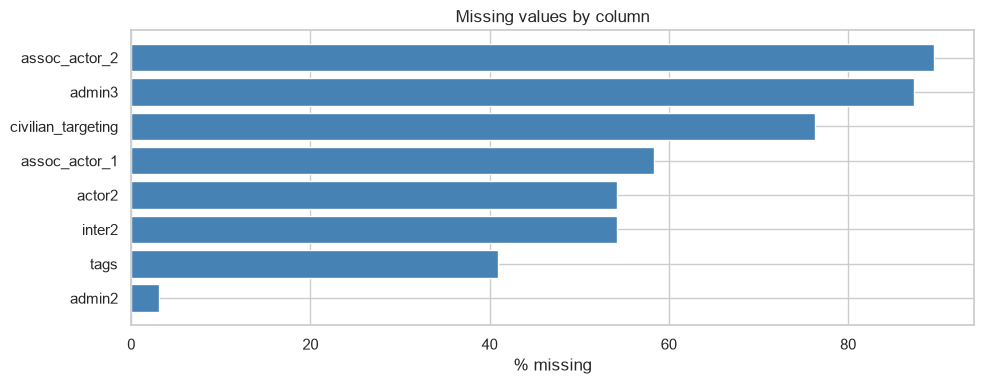

In [22]:
# 5. Handle Missing Values
null_counts = df.null_count().row(0)
missing = pl.DataFrame({"column": df.columns, "n_missing": null_counts})
missing = missing.with_columns((pl.col("n_missing") / df.height * 100).round(2).alias("pct_missing"))
missing = missing.filter(pl.col("n_missing") > 0).sort("pct_missing", descending=True)
display(missing)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(missing["column"], missing["pct_missing"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()


## 5. Most Common Categories

Bar charts of the leading values for `event_type`, `disorder_type`, `country`, and `sub_event_type` to see which kinds of events, and which countries, dominate event volume.

**What it shows:** **Protests are the single largest event type — 228,002 events, 52.6% of all rows** — driven almost entirely by "Peaceful protest" as the sub-event type, consistent with `disorder_type` being led by **Demonstrations** (243,643 events). By country, **Mexico (95,647), Brazil (91,436), and the United States (74,042)** together account for over half of all recorded events, with Colombia and Venezuela a clear second tier. The dataset's volume is dominated by demonstration activity in a handful of large countries, not evenly spread political violence.

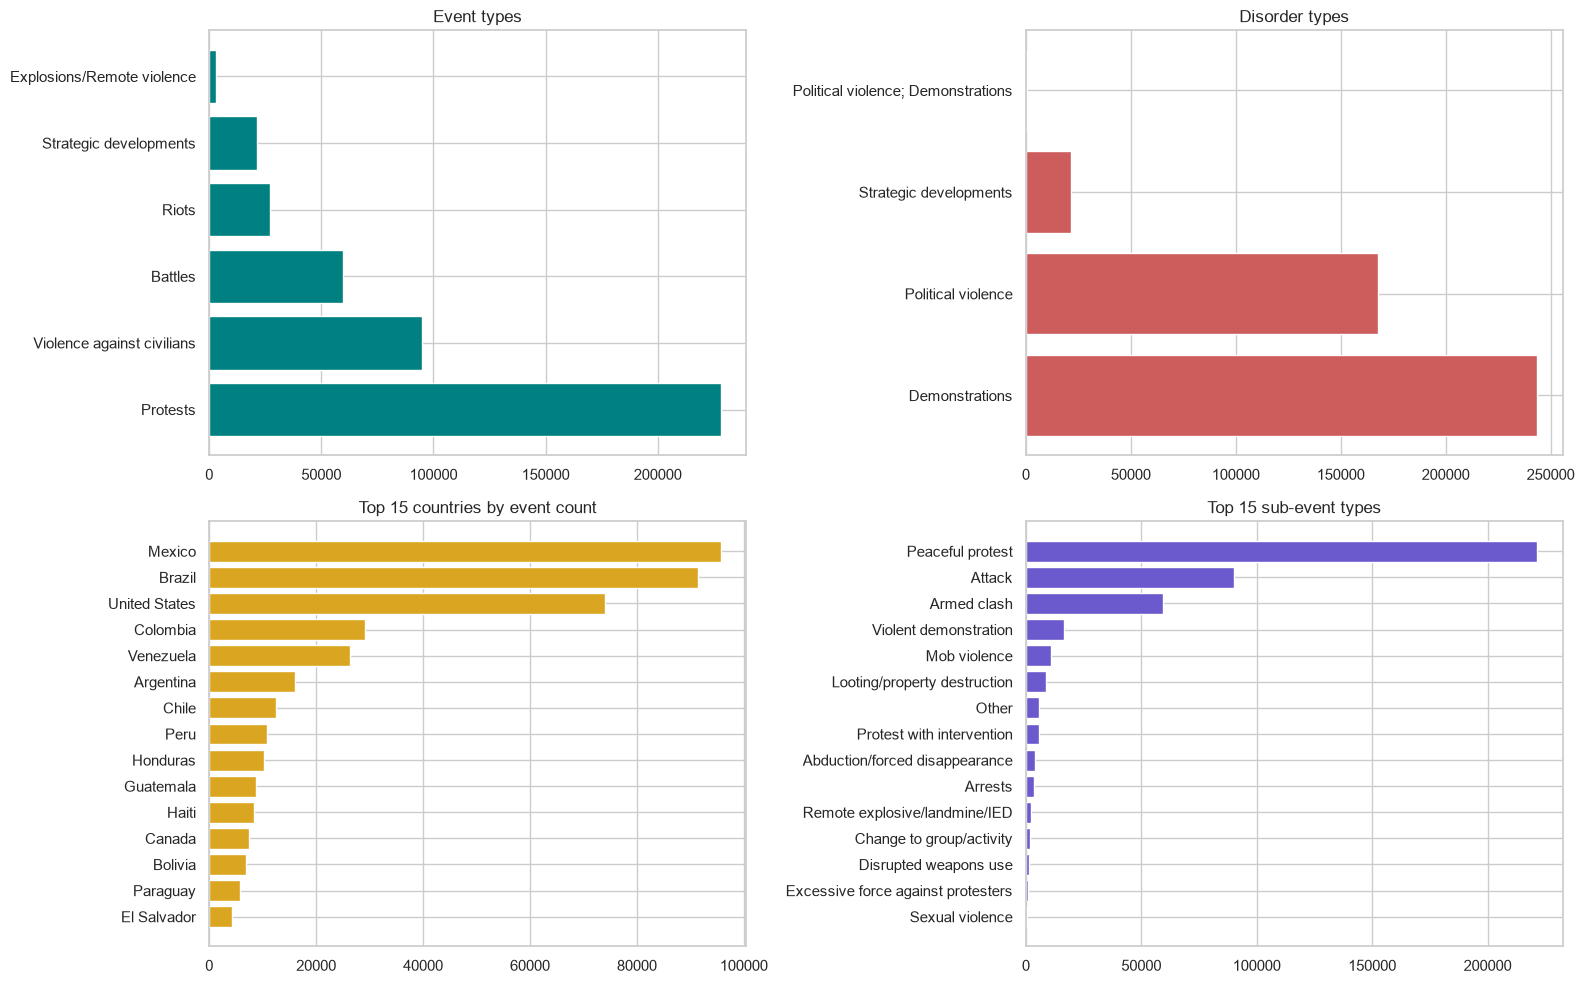

In [23]:
# 6. Analyze Categorical Features — most common categories
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def barh_counts(ax, col, color, top_n=None, title=None, invert=False):
    vc = df[col].value_counts().sort("count", descending=True)
    if top_n:
        vc = vc.head(top_n)
    ax.barh(vc[col], vc["count"], color=color)
    if invert:
        ax.invert_yaxis()
    ax.set_title(title or col)

barh_counts(axes[0, 0], "event_type", "teal", title="Event types")
barh_counts(axes[0, 1], "disorder_type", "indianred", title="Disorder types")
barh_counts(axes[1, 0], "country", "goldenrod", top_n=15, title="Top 15 countries by event count", invert=True)
barh_counts(axes[1, 1], "sub_event_type", "slateblue", top_n=15, title="Top 15 sub-event types", invert=True)

plt.tight_layout()
plt.show()


## 6. Trends Over Time & Leading Actors

Plot event volume by year, identify the most frequently recorded primary actors (`actor1`), and tabulate the most common actor-interaction types.

**What it shows:** Event counts rise sharply from **~50K/year in 2018–2019 to a plateau of 68–71K/year in 2020–2023** (2024 is partial, ending in November), suggesting some combination of a real increase in unrest and improved ACLED coverage over time. "Protesters (United States)" is the single largest `actor1` category (68,322 events), reflecting the scale of U.S. protest activity captured here. The interaction breakdown confirms the protest skew — **"Protesters only" is the top interaction type (218,367 events, ~50%)** — followed by "Political militia–Civilians" (93,091), the clearest signal of one-sided violence against non-combatants.

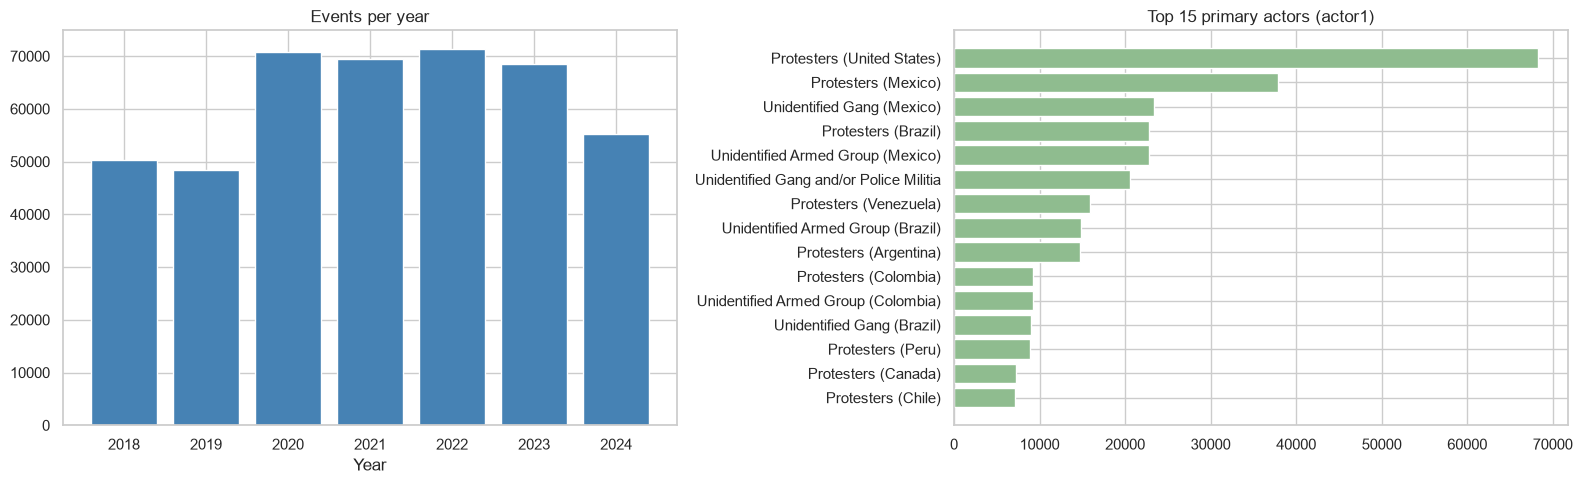


Top 10 actor interactions:
shape: (10, 2)
┌─────────────────────────────────────┬────────┐
│ interaction                         ┆ count  │
│ ---                                 ┆ ---    │
│ str                                 ┆ u32    │
╞═════════════════════════════════════╪════════╡
│ Protesters only                     ┆ 218367 │
│ Political militia-Civilians         ┆ 93091  │
│ State forces-Political militia      ┆ 38553  │
│ Political militia-Political militia ┆ 23955  │
│ Rioters only                        ┆ 8854   │
│ State forces-Rioters                ┆ 8786   │
│ Rioters-Civilians                   ┆ 7533   │
│ State forces-Civilians              ┆ 6621   │
│ State forces-Protesters             ┆ 5697   │
│ Protesters-Protesters               ┆ 3189   │
└─────────────────────────────────────┴────────┘


In [24]:
# 6b. Temporal trends and top actors
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

year_counts = df["year"].value_counts().sort("year")
axes[0].bar(year_counts["year"], year_counts["count"], color="steelblue")
axes[0].set_title("Events per year")
axes[0].set_xlabel("Year")

top_actors = df["actor1"].value_counts().sort("count", descending=True).head(15)
axes[1].barh(top_actors["actor1"], top_actors["count"], color="darkseagreen")
axes[1].invert_yaxis()
axes[1].set_title("Top 15 primary actors (actor1)")

plt.tight_layout()
plt.show()

print("\nTop 10 actor interactions:")
print(df["interaction"].value_counts().sort("count", descending=True).head(10))


## 7. Fatalities: Distribution & Extremes

Look at how fatalities are distributed across events, compare fatality distributions across event types, and surface the single deadliest recorded events.

**What it shows:** **74.7% of events have zero fatalities**, and the dataset records **159,865 total fatalities** across ~434K events — violence is common, lethal violence is comparatively rare. When events are deadly, `event_type` matters a lot: "Battles" carries a materially higher fatality distribution than "Riots" or "Protests." The five deadliest single events are all **gang or armed-group attacks in Haiti** (up to 134 deaths in a 2022 Port-au-Prince gang clash) plus a 2018 Venezuela riot — the extreme tail of this dataset is Haitian gang violence, not state conflict.

Total fatalities: 159,865
Events with 0 fatalities: 74.7%
Max fatalities in a single event: 134


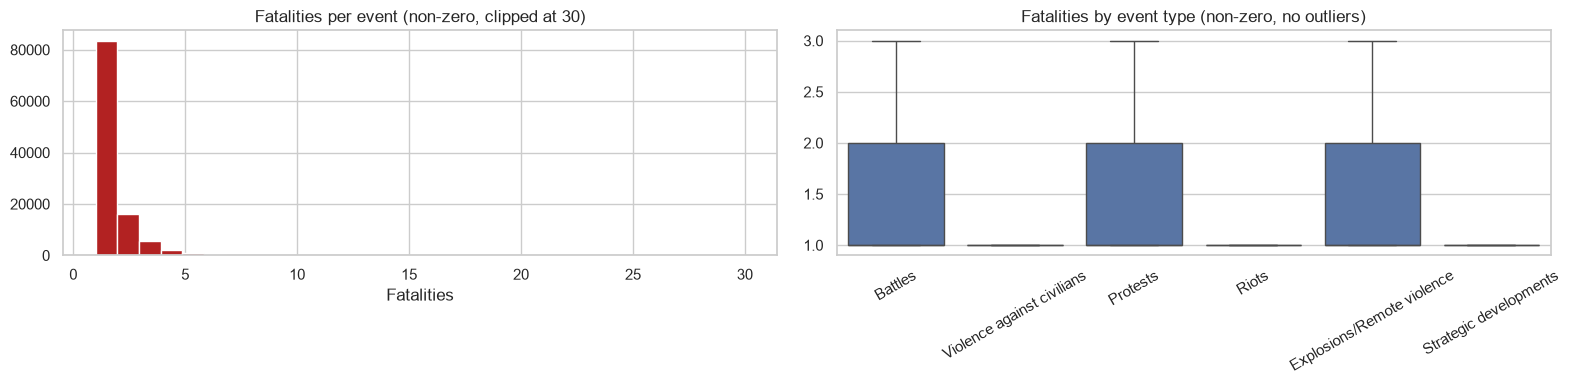


Deadliest single events:


event_date,country,event_type,sub_event_type,actor1,fatalities
date,str,str,str,str,i64
2022-07-07,"""Haiti""","""Battles""","""Armed clash""","""G-9 Gang""",134
2024-10-03,"""Haiti""","""Violence against civilians""","""Attack""","""Baz Gran Grif de Savien Gang""",115
2023-04-08,"""Haiti""","""Violence against civilians""","""Sexual violence""","""Terre Noire Gang""",72
2018-11-13,"""Haiti""","""Violence against civilians""","""Sexual violence""","""Base Nan Chabon Gang""",71
2018-03-28,"""Venezuela""","""Riots""","""Mob violence""","""Rioters (Venezuela)""",68


In [25]:
# 7. Analyze Numerical Features — fatalities distribution
print(f"Total fatalities: {df['fatalities'].sum():,}")
print(f"Events with 0 fatalities: {(df['fatalities'] == 0).mean():.1%}")
print(f"Max fatalities in a single event: {df['fatalities'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
nonzero = df.filter(pl.col("fatalities") > 0)["fatalities"].clip(upper_bound=30)
axes[0].hist(nonzero.to_numpy(), bins=30, color="firebrick")
axes[0].set_title("Fatalities per event (non-zero, clipped at 30)")
axes[0].set_xlabel("Fatalities")

lethal_events = df.filter(pl.col("fatalities") > 0)
sns.boxplot(x=lethal_events["event_type"].to_list(), y=lethal_events["fatalities"].to_numpy(),
            ax=axes[1], showfliers=False)
axes[1].set_title("Fatalities by event type (non-zero, no outliers)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("\nDeadliest single events:")
display(
    df.sort("fatalities", descending=True)
      .head(5)
      .select(["event_date", "country", "event_type", "sub_event_type", "actor1", "fatalities"])
)


## 8. Correlations & Fatalities by Country

Check for linear relationships among the numeric fields, and rank countries by total fatalities to see where lethal violence is concentrated, as opposed to just event volume.

**What it shows:** The numeric correlation matrix is unremarkable — `year`, coordinates, and precision flags are essentially uncorrelated with `fatalities`, meaning **lethality isn't explained by geography or a time trend on its own**; it's driven by categorical factors like actor and event type instead (tested formally in Section 9). Ranking countries by total deaths reshuffles the earlier volume leaderboard: **Mexico (58,120) and Brazil (47,608) still lead**, but **Venezuela, Colombia, and Haiti** move up relative to their event counts — a larger share of their events turn deadly.

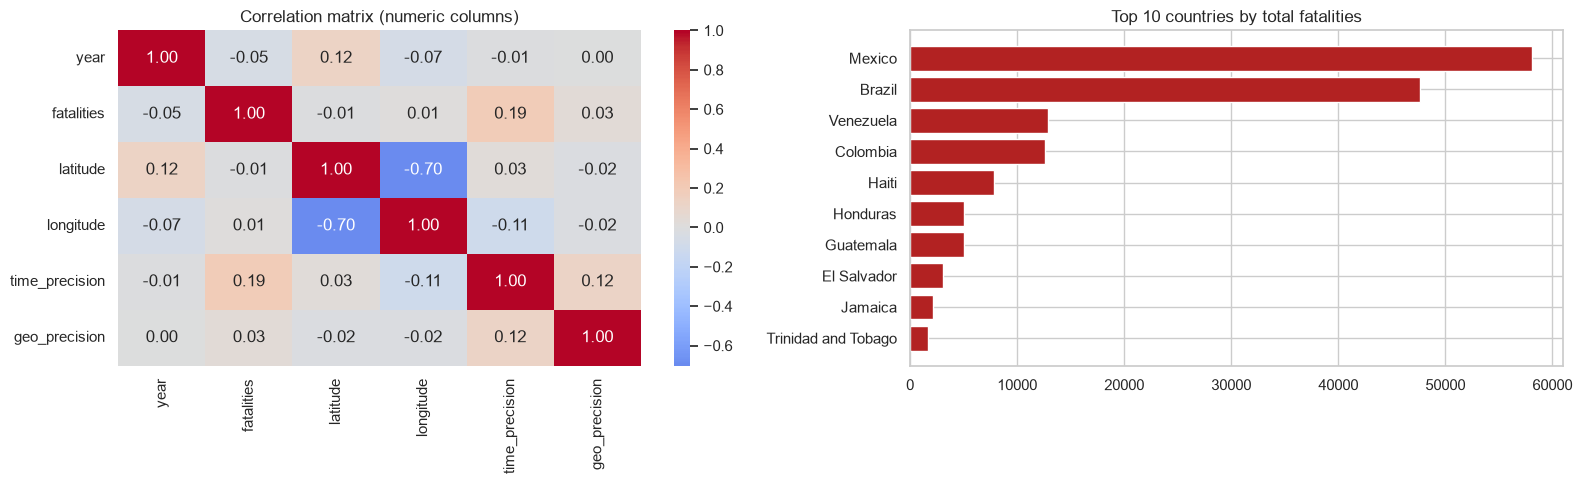

In [26]:
# 8. Correlation Analysis (numeric) + fatality shares by country
num_cols = ["year", "fatalities", "latitude", "longitude", "time_precision", "geo_precision"]
corr = df.select(num_cols).corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(corr.to_numpy(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=num_cols, yticklabels=num_cols, ax=axes[0])
axes[0].set_title("Correlation matrix (numeric columns)")

fat_by_country = (
    df.group_by("country").agg(pl.col("fatalities").sum())
      .sort("fatalities", descending=True)
      .head(10)
)
axes[1].barh(fat_by_country["country"], fat_by_country["fatalities"], color="firebrick")
axes[1].invert_yaxis()
axes[1].set_title("Top 10 countries by total fatalities")
plt.tight_layout()
plt.show()


## 9. What Actually Predicts Lethality?

Move from description to inference: chi-square tests (with Cramér's V effect sizes) for whether categorical factors are associated with an event being lethal, a Kruskal-Wallis test for whether fatality counts differ by event type, and lethality rates broken out by event type.

**What it shows:** Every factor tested comes back statistically significant (p ≈ 0), but at this sample size significance alone isn't informative — the effect sizes (Cramér's V) tell the real story. **`event_type` (V=0.77), `interaction` (V=0.74), and `disorder_type` (V=0.72) are strong predictors of lethality**, while `country` (V=0.42) and especially `source_scale` (V=0.18) are comparatively weak. The lethality-rate table confirms it directly: **"Violence against civilians" is lethal 79.1% of the time**, "Battles" 53.8%, while "Protests" are lethal only 0.1% of the time. The takeaway: **what kind of event it is matters far more than where it happens** for predicting whether anyone dies.

In [27]:
# 9. Feature Significance Exploration
# 9a. Chi-square: are categorical factors associated with whether an event is lethal?
df = df.with_columns([
    (pl.col("fatalities") > 0).cast(pl.Int8).alias("lethal"),
    pl.col("civilian_targeting").is_not_null().cast(pl.Int8).alias("civ_targeted"),
])

results = []
for col in ["event_type", "disorder_type", "country", "inter1", "interaction", "source_scale"]:
    ct = (
        df.group_by([col, "lethal"]).len()
          .pivot(values="len", index=col, on="lethal")
          .fill_null(0)
          .drop(col)
          .to_numpy()
    )
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))  # effect size
    results.append({"factor": col, "chi2": chi2, "p_value": p, "cramers_v": cramers_v})

sig = pl.DataFrame(results).sort("cramers_v", descending=True)
print("Association of categorical factors with lethality (Cramér's V = effect size):")
display(sig)

# 9b. Kruskal-Wallis: do fatality counts differ across event types?
event_types = df["event_type"].unique().to_list()
groups = [df.filter(pl.col("event_type") == et)["fatalities"].to_numpy() for et in event_types]
h, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis (fatalities ~ event_type): H={h:,.0f}, p={p:.2e}")

# 9c. Lethality rate by event type
print("\nLethality rate by event type:")
display(
    df.group_by("event_type")
      .agg([pl.col("lethal").mean().alias("mean"), pl.col("lethal").count().alias("count")])
      .sort("mean", descending=True)
)


Association of categorical factors with lethality (Cramér's V = effect size):


factor,chi2,p_value,cramers_v
str,f64,f64,f64
"""event_type""",260279.691851,0.0,0.774563
"""interaction""",238944.931609,0.0,0.74214
"""disorder_type""",227390.496639,0.0,0.723974
"""inter1""",217665.22988,0.0,0.708323
"""country""",76302.577504,0.0,0.419379
"""source_scale""",14715.446392,0.0,0.184172


Kruskal-Wallis (fatalities ~ event_type): H=254,339, p=0.00e+00

Lethality rate by event type:


event_type,mean,count
str,f64,u32
"""Violence against civilians""",0.79148,94840
"""Battles""",0.538323,59520
"""Explosions/Remote violence""",0.104749,2864
"""Riots""",0.067281,27140
"""Strategic developments""",0.003633,21471
"""Protests""",0.001189,228002


## 10. Putting It Together: Geography, Time, and Civilian Targeting

Map a sample of events by disorder type to see spatial patterns, chart how the event-type mix has shifted year over year, and examine which countries see the most civilian-targeting events — both in raw count and as a share of their activity.

**What it shows:** The geographic scatter shows demonstrations clustering around major urban centers (consistent with the U.S./Mexico/Brazil dominance seen earlier), while political-violence events concentrate more narrowly around conflict zones like Haiti, Colombia, and Venezuela. The year-over-year composition chart shows the protest share ebbing and flowing rather than trending steadily in one direction. On civilian targeting, **Mexico and Brazil have the most such events in raw terms**, but rate tells a different story: **Mexico (42.9%), Honduras (35.7%), and Guatemala (33.8%) have the highest per-event civilian-targeting rates**, while high-volume Argentina and the U.S. sit under 2% — civilian targeting is concentrated in Central America and Mexico's gang-conflict dynamics, not spread evenly with overall event volume.

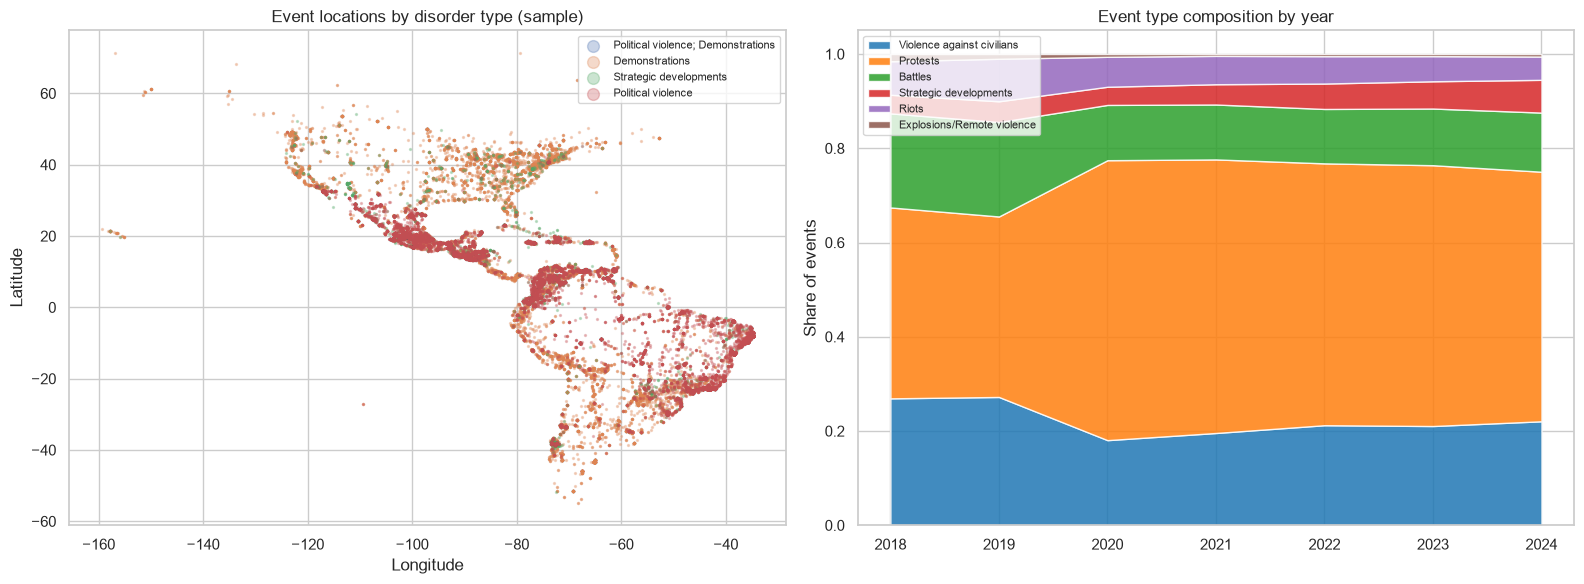

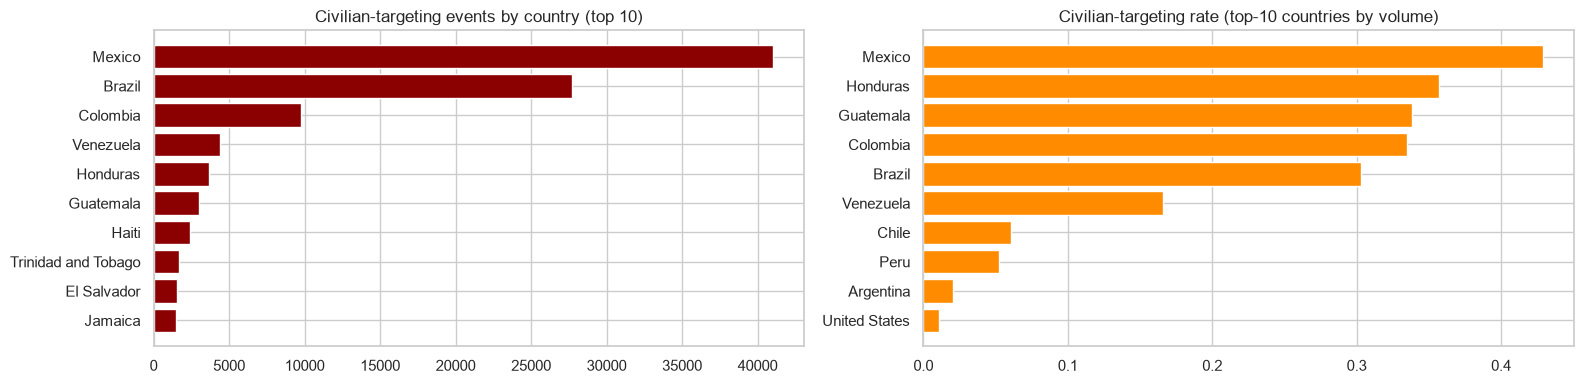

In [28]:
# 10. Visualize Key Relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Geographic scatter of events, colored by disorder type (sampled for speed)
sample = df.sample(n=min(40000, df.height), seed=42)
for dt in sample["disorder_type"].unique().to_list():
    g = sample.filter(pl.col("disorder_type") == dt)
    axes[0].scatter(g["longitude"], g["latitude"], s=2, alpha=0.3, label=dt)
axes[0].legend(markerscale=6, fontsize=8)
axes[0].set_title("Event locations by disorder type (sample)")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

# Event type mix over time
mix = (
    df.group_by(["year", "event_type"]).len()
      .pivot(values="len", index="year", on="event_type")
      .fill_null(0)
      .sort("year")
)
mix_years = mix["year"].to_list()
mix_cols = [c for c in mix.columns if c != "year"]
mix_matrix = mix.select(mix_cols).to_numpy()
shares = mix_matrix / mix_matrix.sum(axis=1, keepdims=True)
axes[1].stackplot(mix_years, shares.T, labels=mix_cols, colors=plt.cm.tab10.colors, alpha=0.85)
axes[1].set_title("Event type composition by year")
axes[1].set_ylabel("Share of events")
axes[1].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

# Civilian targeting: which countries and event types?
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
top10_countries = df["country"].value_counts().sort("count", descending=True).head(10)["country"].to_list()

civ_by_country = (
    df.filter(pl.col("civ_targeted") == 1)
      .group_by("country").len()
      .sort("len", descending=True)
      .head(10)
)
axes[0].barh(civ_by_country["country"], civ_by_country["len"], color="darkred")
axes[0].invert_yaxis()
axes[0].set_title("Civilian-targeting events by country (top 10)")

civ_rate = (
    df.filter(pl.col("country").is_in(top10_countries))
      .group_by("country").agg(pl.col("civ_targeted").mean().alias("rate"))
      .sort("rate")
)
axes[1].barh(civ_rate["country"], civ_rate["rate"], color="darkorange")
axes[1].set_title("Civilian-targeting rate (top-10 countries by volume)")
plt.tight_layout()
plt.show()


## 11. Cartel Rivalry Network Overlay on Mexico Events

Bring in the companion network dataset from Prieto-Curiel et al. (2023, *Science* 381) — `cartel_network/` — to see **which cartel was behind which event and where**. Its `BACRIM2020_Nodes/Rivals/Alliances.csv` files describe a snapshot of 150 cartels and their conflict network as of 2020; here they're used to (1) tag each Mexico ACLED event with the cartel named in `actor1`/`actor2`, and (2) draw the rivalry network on top of those events, positioning each cartel at the mean location of its *actual* recorded events (not the network file's single listed state, which is only a nominal home base).

Matching ACLED's free-text actor names to `BACRIM2020` node names isn't exact — different languages, abbreviations, and spellings — so a manual crosswalk covers the ~35 cartels with enough named-actor events to match reliably. That's a small fraction of the 300+ distinct named actors in the data, but it captures the large majority of cartel-attributed event *volume*; the long tail of small local gangs (1-3 events each, often a single ACLED mention) is left unmatched rather than guessed at.

In [29]:
# 11a. Load the cartel network data and build an ACLED-actor -> BACRIM2020-node crosswalk
import plotly.graph_objects as go

nodes = pl.read_csv("cartel_network/BACRIM2020_Nodes.csv")
rivals = pl.read_csv("cartel_network/BACRIM2020_Rivals.csv")
alliances = pl.read_csv("cartel_network/BACRIM2020_Alliances.csv")
node_lookup = {row["Node"]: {"Group": row["Group"], "ShortName": row["ShortName"]}
               for row in nodes.iter_rows(named=True)}
group_map = {k: v["Group"] for k, v in node_lookup.items()}
short_map = {k: v["ShortName"] for k, v in node_lookup.items()}

# Manual crosswalk: ACLED actor1/actor2 string -> BACRIM2020 Node id.
# Built by inspecting the ~35 most frequent named cartel actors among Mexico events
# and matching each to the closest BACRIM2020 node by name/alias/lineage.
CARTEL_CROSSWALK = {
    "CJNG: Jalisco New Generation Cartel": "N10025",
    "Sinaloa Cartel": "N10013",
    "CDN: Cartel del Noreste": "N10019",
    "La Familia Michoacana Cartel": "N10076",  # matched to its 2020 successor, La Nueva Familia Michoacana
    "Santa Rosa de Lima Cartel": "N10012",
    "Los Viagras Gang": "N10133",
    "Gulf Cartel": "N10017",
    "La Union Tepito": "N10081",
    "Los Chapitos Gang": "N10091",
    "Los Ardillos Gang": "N10084",
    "Los Zetas": "N10134",
    "Los Metros Gang": "N10108",
    "Tijuana Cartel": "N10007",  # historic Arellano Felix organization
    "Los Caballeros Templarios Gang": "N10003",
    "Tropa del Infierno Gang": "N10147",
    "Gente Nueva Gang": "N10058",
    "Los Tlacos Gang": "N10130",
    "Grupo Sombra": "N10061",
    "Cartel de Tlahuac": "N10015",
    "Fuerza Anti Union": "N10057",
    "Los Pelones Cartel": "N10116",
    "Guerreros Unidos Gang": "N10063",
    "Los Zetas Vieja Escuela Gang": "N10150",
    "Beltran Leyva Cartel": "N10008",
    "Caborca Cartel": "N10004",
    "Cartel del Sur": "N10022",
    "CTNG: Tijuana New Generation Cartel": "N10030",
    "Los Sinaloas Gang": "N10126",
    "Los Colombianos Gang": "N10095",
    "Cartel del Abuelo": "N10016",
    "Los Talibanes Gang": "N10127",
    "Los Rojos Gang": "N10120",
    "Los Cuinis Gang": "N10096",
    "Juarez Cartel": "N10005",
}
print(f"{len(CARTEL_CROSSWALK)} ACLED actor names mapped to BACRIM2020 cartel nodes")


34 ACLED actor names mapped to BACRIM2020 cartel nodes


In [30]:
# 11b. Tag every Mexico event where actor1 and/or actor2 is a mapped cartel
mx = df.filter(pl.col("country") == "Mexico").with_columns([
    pl.col("actor1").replace_strict(CARTEL_CROSSWALK, default=None, return_dtype=pl.Utf8).alias("cartel_node_1"),
    pl.col("actor2").replace_strict(CARTEL_CROSSWALK, default=None, return_dtype=pl.Utf8).alias("cartel_node_2"),
])

parts = [
    mx.filter(pl.col(node_col).is_not_null()).with_columns(pl.col(node_col).alias("cartel_node"))
    for node_col in ["cartel_node_1", "cartel_node_2"]
]
cartel_events = pl.concat(parts).with_columns([
    pl.col("cartel_node").replace_strict(group_map, return_dtype=pl.Utf8).alias("cartel_name"),
    pl.col("cartel_node").replace_strict(short_map, return_dtype=pl.Utf8).alias("cartel_short"),
])
cartel_events = cartel_events.unique(subset=["event_id_cnty", "cartel_node"], keep="first")

n_unique_events = cartel_events["event_id_cnty"].n_unique()
print(f"Cartel-attributed events: {n_unique_events:,} unique events "
      f"({cartel_events.height:,} event-cartel pairs, since a few events involve two mapped cartels)")
print(f"Cartels represented: {cartel_events['cartel_node'].n_unique()} of {nodes.height} in the network")
print(f"Share of all Mexico events with a mapped cartel actor: {n_unique_events / mx.height:.1%}")
cartel_events["cartel_short"].value_counts().sort("count", descending=True).head(15)


Cartel-attributed events: 2,566 unique events (2,836 event-cartel pairs, since a few events involve two mapped cartels)
Cartels represented: 34 of 150 in the network
Share of all Mexico events with a mapped cartel actor: 2.7%


cartel_short,count
str,u32
"""CJNG""",1113
"""Sinaloa""",376
"""Noreste""",183
"""NFMichoacana""",174
"""Santa Rosa de Lima""",152
…,…
"""Metros""",33
"""Zetas""",32
"""Rojos""",29


In [31]:
# 11c. Position each cartel at the mean location of its actual events, and keep rivalry
# edges where both sides have events on the map
centroids = (
    cartel_events.group_by("cartel_node")
    .agg([
        pl.col("latitude").mean().alias("lat"),
        pl.col("longitude").mean().alias("lon"),
        pl.col("event_id_cnty").n_unique().alias("n_events"),
    ])
).with_columns(pl.col("cartel_node").replace_strict(short_map, return_dtype=pl.Utf8).alias("short"))

centroid_lookup = {row["cartel_node"]: (row["lat"], row["lon"]) for row in centroids.iter_rows(named=True)}

mapped_ids = set(cartel_events["cartel_node"].unique().to_list())
riv = rivals.filter(pl.col("Node").is_in(mapped_ids) & pl.col("RNode").is_in(mapped_ids))
riv = riv.with_columns(
    pl.concat_str([pl.min_horizontal("Node", "RNode"), pl.max_horizontal("Node", "RNode")], separator="_").alias("pair")
)
riv = riv.unique(subset=["pair"], keep="first")

print(f"Rivalry edges plotted: {riv.height} of {rivals.height // 2} unique rivalries in the 2020 network "
      f"(the rest involve a cartel with no matched events in this data)")
riv.select(["Group", "RGroup", "weight"]).sort("weight", descending=True).head(10)


Rivalry edges plotted: 45 of 63 unique rivalries in the 2020 network (the rest involve a cartel with no matched events in this data)


Group,RGroup,weight
str,str,i64
"""Cártel Jalisco Nueva Generación (CJNG)""","""La Nueva Familia Michoacana""",13
"""Cártel de Sinaloa""","""Cártel Jalisco Nueva Generación (CJNG)""",7
"""Cártel del Noreste""","""Cártel Jalisco Nueva Generación (CJNG)""",6
"""Fuerza Anti-Unión Tepito""","""La Unión Tepito""",5
"""Caballeros Templarios""","""Guerreros Unidos""",4
"""Cártel Jalisco Nueva Generación (CJNG)""","""Zetas Vieja Escuela""",3
"""Guerreros Unidos""","""La Nueva Familia Michoacana""",3
"""Cártel de Tláhuac""","""Cártel Jalisco Nueva Generación (CJNG)""",3
"""Cártel Jalisco Nueva Generación (CJNG)""","""Caballeros Templarios""",3


In [33]:
# 11d. Plot events on a Mexico map, colored by cartel, with rivalry-network edges overlaid
top_cartels = (
    cartel_events["cartel_short"].value_counts().sort("count", descending=True).head(12)["cartel_short"].to_list()
)
palette = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#42d4f4",
           "#f032e6", "#bfef45", "#fa8072", "#469990", "#9A6324", "#800000"]
color_map = {c: palette[i % len(palette)] for i, c in enumerate(top_cartels)}

fig = go.Figure()

max_w = riv["weight"].max()
for r in riv.iter_rows(named=True):
    lat1, lon1 = centroid_lookup[r["Node"]]
    lat2, lon2 = centroid_lookup[r["RNode"]]
    fig.add_trace(go.Scattergeo(
        lat=[lat1, lat2], lon=[lon1, lon2], mode="lines",
        line=dict(width=1 + 4 * r["weight"] / max_w, color="rgba(180,30,30,0.45)"),
        hoverinfo="text", text=f"{r['Group']} vs {r['RGroup']}: rivals in {r['weight']} state(s) (2020)",
        showlegend=False,
    ))

plot_df = cartel_events.with_columns(
    pl.when(pl.col("cartel_short").is_in(top_cartels))
      .then(pl.col("cartel_short"))
      .otherwise(pl.lit("Other cartels"))
      .alias("group")
).with_columns(
    (pl.col("cartel_name") + "<br>" + pl.col("event_date").cast(pl.Utf8) + " \u2014 " + pl.col("sub_event_type")
     + "<br>" + pl.col("admin1").cast(pl.Utf8) + " | fatalities: " + pl.col("fatalities").cast(pl.Utf8))
    .alias("hover_text")
)
for name in plot_df["group"].unique().to_list():
    sub = plot_df.filter(pl.col("group") == name)
    fig.add_trace(go.Scattergeo(
        lat=sub["latitude"].to_numpy(), lon=sub["longitude"].to_numpy(), mode="markers",
        marker=dict(size=5, color=color_map.get(name, "#888888"), opacity=0.65,
                    line=dict(width=0.3, color="white")),
        name=name,
        text=sub["hover_text"].to_list(),
        hoverinfo="text",
    ))

fig.add_trace(go.Scattergeo(
    lat=centroids["lat"].to_numpy(), lon=centroids["lon"].to_numpy(), mode="text",
    text=centroids["short"].to_list(), textfont=dict(size=9, color="black"),
    showlegend=False, hoverinfo="skip",
))

fig.update_geos(
    scope="north america", showcountries=True, showsubunits=True,
    subunitcolor="rgba(0,0,0,0.3)", showland=True, landcolor="rgb(245,245,240)",
    lataxis_range=[13, 33], lonaxis_range=[-119, -85],
)
fig.update_layout(
    title="Mexico: cartel-attributed ACLED events (2018-2024) with 2020 rivalry network overlaid",
    height=800, legend=dict(itemsizing="constant", title="Cartel (top 12 by event count)"),
)
fig.show()


**What it shows:** 2,566 Mexico events (2.7% of all Mexico events, since most `actor1`/`actor2` values are generic — "Unidentified Gang," "Protesters" — rather than a named cartel) are attributable to 34 of the network's 150 cartels. **CJNG dominates by a wide margin (1,113 events)**, followed by Sinaloa (376), Cartel del Noreste (183), and La Nueva Familia Michoacana (174) — consistent with the paper's finding that these are the nationally-present cartels driving most conflict. The rivalry overlay recovers real, well-documented feuds directly from the geography: **CJNG's heaviest rivalry line runs to La Nueva Familia Michoacana** (13 states of overlap in the 2020 network) and its events cluster in Jalisco/Bajío while NFM's cluster in Michoacán, right where that fight has played out; **Cartel del Golfo and Cartel del Noreste** (the Zetas' two main successor factions) sit next to each other on the Gulf coast with a direct rivalry edge; and **La Unión Tepito vs. Fuerza Anti-Unión Tepito** shows up as a tight, high-weight edge, matching their known turf war within Mexico City. 45 of the 63 rivalry pairs in the 2020 network have both sides represented in the event data — the rest involve smaller cartels with too few (or zero) ACLED mentions to place on the map. Hover any point for the exact date, sub-event type, location, and fatalities; hover an edge for the two cartels and how many states they contested in 2020.

## Conclusions

Tying back to the three goals set out at the top:

1. **Shape & structure:** ~434K events, 2018–2024, 31 columns, with missingness that is structural (fields only apply to a subset of events) rather than a data-quality problem.
2. **Most common values:** The dataset skews heavily toward **peaceful protest activity concentrated in Mexico, Brazil, and the U.S.** — event volume is not a good proxy for violence.
3. **Drivers of lethality:** **Event type and actor interaction are by far the strongest predictors of whether an event is lethal** (Cramér's V 0.7+), while geography and source scale matter much less. Deadly outcomes and civilian targeting are concentrated in a distinct subset of countries — Haiti, Mexico, Honduras, Guatemala, Colombia, Venezuela — that looks quite different from the countries that simply generate the most events.